# House Rent Prediction

This project predicts house rent using machine learning techniques.

## Data Preprocessing

- Converted Posted On into datetime
- Extracted Day, Month and DayOfWeek
- Extracted Current Floor and Total Floor
- Frequency encoded Area Locality
- Applied log transformation on Rent

## Import Libraries

In [23]:
# Data manipulation

import pandas as pd
import numpy as np

# Data visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Model selection

from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV

# Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

# Models

from sklearn.linear_model import LinearRegression,Ridge,Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import ( RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor )

# Evaluation Metrics

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

# Model Saving

import joblib

# Ignore Warnings

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [24]:

df=pd.read_csv('House_Rent_Dataset.csv')

# Create a copy of the original dataset
# to preserve raw data during preprocessing

data=df.copy()

In [25]:
# Display first five records

data.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [26]:
# Check dataset shape

data.shape

(4746, 12)

In [27]:
# Check data types

data.dtypes

Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

## Exploratory Data Analysis

In [28]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [29]:
# Summary statistics of numerical features

data.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [30]:
# Check missing values

data.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [31]:
# Analyze rent distribution

data['Rent'].describe()

count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64

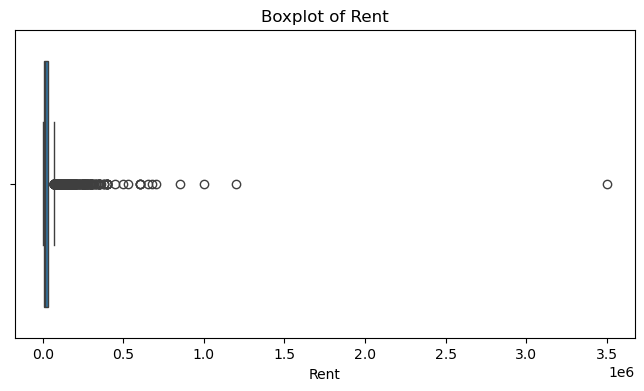

In [32]:
# Visualize outliers in rent

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Rent'])
plt.title('Boxplot of Rent')

plt.show()

## Data Cleaning

In [33]:
# Convert 'Posted On' column to datetime format

data['Posted On']=pd.to_datetime(data['Posted On'])

In [34]:
# Split Floor column into Current Floor and Total Floor

data[['Current Floor','Total Floor']]=data['Floor'].str.split(' out of ',expand=True)

In [35]:
# Remove original Floor column

data.drop(columns='Floor',inplace=True)

In [36]:
# Check missing values after floor feature extraction

data.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
Current Floor        0
Total Floor          4
dtype: int64

In [37]:
# Convert Total Floor to numeric and replace invalid values with NaN

data['Total Floor'] = pd.to_numeric(data['Total Floor'], errors='coerce')

In [38]:
# Impute missing values in Total Floor using median

data['Total Floor']=data['Total Floor'].fillna(data['Total Floor'].median())

In [39]:
# Convert floor categories into numerical values

data['Current Floor']=data['Current Floor'].replace(['Ground','Upper Basement','Lower Basement'],[0,-1,-2])

In [40]:
# Convert Total Floor to integer data type

data['Total Floor'] =data['Total Floor'].astype(int)

## Feature Engineering

In [41]:
# Extract useful date features from 'Posted On'

data['day']=data['Posted On'].dt.day
data['Month']=data['Posted On'].dt.month
data['dayofweek']=data['Posted On'].dt.dayofweek

# Drop original date column after feature extraction

data=data.drop(columns='Posted On')

In [42]:
# Apply Frequency Encoding to Area Locality
freq = data['Area Locality'].value_counts().to_dict()

data['Area_Locality_Freq'] = data['Area Locality'].map(freq)

# Drop original categorical column after encoding
data.drop(columns='Area Locality', inplace=True)

data.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current Floor,Total Floor,day,Month,dayofweek,Area_Locality_Freq
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,0,2,18,5,2,2
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1,3,13,5,4,2
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1,3,16,5,0,16
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,1,2,4,7,0,2
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner,1,2,9,5,0,1


## Model Comparison

In [43]:
# Define Features and Target Variable

X=data.drop(columns='Rent')

# Log-transform the target variable to handle skewness
# and reduce the impact of extreme rent values.

y_log=np.log1p(data['Rent'])

# Categorical features encoded using One-Hot Encoding

ohe_col=['Area Type','City','Tenant Preferred','Point of Contact']

# Ordinal feature encoded using Ordinal Encoding

ordinal_col=['Furnishing Status']

# Numerical features

num_col=X.select_dtypes(exclude='object').columns.tolist()

# Split Data into Training and Testing Sets

X_train,X_test,y_train,y_test=train_test_split(X,y_log,test_size=0.2,random_state=42)

# Create Data Preprocessing Pipeline

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=1000000),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42)
}


preprocess=ColumnTransformer(
    [
        (
            'num',Pipeline(
                [
                    ('imputer',SimpleImputer(strategy='median')),
                    ('scaler',StandardScaler())
                ]
            ),num_col
        ),
        
        ('onehot',Pipeline(
                [
                    ('imputer',SimpleImputer(strategy='most_frequent')),
                    ('encoder',OneHotEncoder( handle_unknown='ignore'))
                ]
            ),ohe_col
        ),

        ('ordinal',Pipeline(
                [
                    ('imputer',SimpleImputer(strategy='most_frequent')),
                    ('encoder',OrdinalEncoder(categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']]))
                ]
            ),ordinal_col
        )

    ]
)

# Compare Multiple Regression Models Using Cross Validation

result=[]
for name,model in models.items():
    pipe=Pipeline(
        [
            ('preproces',preprocess),
            ('model',model)
        ]
    )
    score=cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    ).mean()
    result.append([name,score])

new_df=pd.DataFrame(result,columns=['Name','score'])
new_df.sort_values(by='score',ascending=False)


,Name,score
7,HistGradientBoosting,0.824459
6,GradientBoosting,0.824416
4,RandomForest,0.813793
1,Ridge,0.810621
0,LinearRegression,0.810619
5,ExtraTrees,0.803336
3,DecisionTree,0.625409
2,Lasso,-0.000819


## Hyperparameter Tuning

In [44]:
# Hyperparameter Tuning for GradientBoostingRegressor

pipe=Pipeline(
    [
        ('preproces',preprocess),
        ('model',GradientBoostingRegressor())
    ]
)

param_grid_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0]
}
gscv_gb=RandomizedSearchCV(
    pipe,
    param_distributions=param_grid_gb,
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=42,
    scoring='r2'
)

gscv_gb.fit(X_train,y_train)

print("Best Parameters:", gscv_gb.best_params_)
print("Best Cross Validation Score:", gscv_gb.best_score_)

Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best Cross Validation Score: 0.8280939481102816


In [45]:
#hyper tuning HistGradientBoosting
pipe=Pipeline(
    [
        ('preproces',preprocess),
        ('model',HistGradientBoostingRegressor())
    ]
)

param_grid_hgb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_leaf': [20, 30, 50],
    'model__l2_regularization': [0, 0.1, 1]
}
gscv_hgb=RandomizedSearchCV(
    pipe,
    param_distributions=param_grid_hgb,
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=42,
    scoring='r2'
)

gscv_hgb.fit(X_train,y_train)

print("Best Parameters:", gscv_hgb.best_params_)
print("Best Cross Validation Score:", gscv_hgb.best_score_)


Best Parameters: {'model__min_samples_leaf': 20, 'model__max_iter': 100, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best Cross Validation Score: 0.8268009858573668


In [46]:
#hyper tuning RandomForestRegressor
pipe=Pipeline(
    [
        ('preproces',preprocess),
        ('model',RandomForestRegressor())
    ]
)

param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

gscv_rf=RandomizedSearchCV(
    pipe,
    param_distributions=param_grid_rf,
    n_iter=30,
    n_jobs=-1,
    cv=5,
    random_state=42,
    scoring='r2'
)

gscv_rf.fit(X_train,y_train)

print("Best Parameters:", gscv_rf.best_params_)
print("Best Cross Validation Score:", gscv_rf.best_score_)

Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}
Best Cross Validation Score: 0.8216153221185237


## Compare Tuned Models

In [47]:
# Compare Tuned Models

results = pd.DataFrame({
    'Model': ['RandomForest','GradientBoosting','HistGradientBoosting'],
    'Best_CV_Score': [
        gscv_rf.best_score_,
        gscv_gb.best_score_,
        gscv_hgb.best_score_
    ]
})

results.sort_values('Best_CV_Score', ascending=False)

,Model,Best_CV_Score
1,GradientBoosting,0.828094
2,HistGradientBoosting,0.826801
0,RandomForest,0.821615


In [48]:
# Best Model Selected After Hyperparameter Tuning

best_model = gscv_gb.best_estimator_

best_model

Pipeline(steps=[('preproces',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BHK', 'Size', 'Bathroom',
                                                   'Total Floor', 'day',
                                                   'Month', 'dayofweek',
                                                   'Area_Locality_Freq']),
                                                 ('onehot',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Area Type', 'City',
                                                   'Tenant Preferred',
                                                   'Point of Contact']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Unfurnished',
                                                                                               'Semi-Furnished',
                                                                                               'Furnished']]))]),
                                                  ['Furnishing Status'])])),
                ('model',
                 GradientBoostingRegressor(min_samples_split=5,
                                           n_estimators=200))])

## Best model selected after model comparison and hyperparameter tuning

In [49]:

# Generate predictions on test data

y_pred_log = best_model.predict(X_test)

# Convert predictions and actual values back to original scale

pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)


## Model Evaluation

In [50]:
print("R2 Score :", r2_score(y_true, pred))
print("MAE      :", mean_absolute_error(y_true, pred))
print("RMSE     :", root_mean_squared_error(y_true, pred))

R2 Score : 0.6930876050191022
MAE      : 10664.541273305786
RMSE     : 34973.74622435734


## Save Trained Model

In [51]:
# Generate frequency mapping from Area Locality feature
# This mapping will be used in the Streamlit application
# to automatically convert locality names into frequency encoded values

freq = data['Area Locality'].value_counts().to_dict()


# Save frequency mapping dictionary

joblib.dump(freq, 'area_locality_freq.pkl')


# Save the best trained model after model comparison
# and hyperparameter tuning

joblib.dump(best_model, 'house_prediction_model.joblib')


# Display success message

print("Model saved successfully!")

Model saved successfully!
